In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import ticker

import MDSplus as mds

import scipy.interpolate as interp
import scipy.integrate as integ
import scipy.special as sp
import scipy.constants as const


In [2]:
plt.rcParams['mathtext.default'] = 'regular'

## <b>Overview</b>
### <b>What is this code for? And its principle?</b>
Two dimonsional magnetic field measurement is necessary for merging experiments (otherwise how do we when know when and where do the plasmas merge?).   
To do so, on TS6, we use 2D pickup coil arrays. The idea, Faraday's law, is simple: the change of magnetic flux in the coil generates voltage, which can be written as
$$V_{coil}=-\frac{\partial\Psi}{\partial t}\approx-NS\frac{\partial B_{avg}}{\partial t}$$
so that 
$$B_{avg}=-\frac{1}{NS}\int V_{coil} \, dt$$
where $V_{coil}$ is the voltage, $\Psi$ is the magnetic flux, $t$ is time, $N$ and $S$ are the turns and area of the coil, and $B$ is the magetic field. Our TS6 magnetic coils use RC integrator to integrate the voltage signal, so that $\int V_{coil} \, dt = RC \, V_{out}$, where $RC$ is the time constant of the coil, and $V_{out}$ is the measured value.     

Finally, we get 
$$B_{avg} = \frac{RC}{NS}V_{out}$$  
Remember that $V_{out}$ is just the measured value, $RC$ and $NS$ are just some calibration constants that someone elso will give you, so this part is actuall super easy (especially with the help of the python pandas module). But keep in mind that $B_{avg}$ is only the time variant part, and there should be a background, which is the equilibrium field along the $Z$ direction. The equations are
$$B_{z, EF}=\frac{\mu_0I}{2\pi}\frac{1}{\sqrt{(R+r)^2+z^2}}\left[K(k)+\frac{R^2-r^2-z^2}{(R+r)^2+z^2-4rR}E(k)\right]$$
$$k^2=\frac{4Rr}{(R+r)^2+z^2}$$

where $R$ is the radius of the equilibrium field coils, $r$ and $z$ is the radial and vertical distance to the center of the equilibrium coils, $\mu$ is the permeability constant, and $I=N\times I_{EF}$ is the current in the coils. $E(k), K(k)$ are the canonical elliptical integral of the first and second kind. Don't get scared by this equation and its name, it can be super easily done with one line of python code. For how this equation comes to play, check [this website](https://tiggerntatie.github.io/emagnet-py/offaxis/off_axis_loop.html). Another very important thing to keep in mind is that, different libraies might calculate canonical elliptical integral using diffent notations. For example, python scipy library takes $m=k^2$ as input instead of $k$. Be careful.

Now we are ready to recover the 2D magnetic field. An initial guess may be to directly pick up the $B_z$ and $B_r$ and plot their stream line. However, a problem is that $B_r$ measurement is very untrustworthy as $B_r$ becomes very small through out the reconnection area. Luckily, in a cylindrical symmetric geometry, this can be solved by the magnetic flux $\Psi$ along the $r$ direction. The contour of $\Psi$ along the $r$ direction should be the magnetic lines on the poloidal plane (if they do not overlap, then the contour should change), and all other parameters can be derived from $\Psi$.
$$\Psi = \int_{r_0}^r 2\pi rB_z \, dr$$
$$B_r=\frac{1}{2\pi r} \frac{\partial \Psi}{\partial z}$$
$$E_t=-\frac{1}{2\pi r}\frac{\partial\Psi}{\partial t} $$




### <b>Miscelluous engineering problems</b>
Theory is straight forward, but engineering is forever imperfect. We always have problems too dirty to be written explicitly out. Throughout development and maintainence of the TS6_0.0 version, I encountered

1. <b>TF shot and offset noise</b>  
   This is related to two issues: TFshot and offset noise. Confusing as its name is, TFshot originates from the fact that the pickup coils in the $Z$ direction do not only pick up magnetic field in the $Z$ direction. Other components, toroidal and radial ones, also exist. The question is that when guide field is used, usually the toroidal field's (TF's) strength is way larger than that of the $Z$ field, imposing great noise. Before we found a better idea to overcome this problem, usually we measure a shot where there is only TF, and substract them from the experiment data. Offset noise is the electric circuit problem where the $V_{out}$ is not 0 when it is supposed to be. Usually, substracting the mean value of the first a tens of points should be enough, but sometimes the offset noise may still remain there after the completion of merging, and we need to substract the offset noise after merging.

   These above problems are previously deemed minor and are being take care of right at the time of reading and saving data (yes, in the previous versions, data reading, TF and offset clearing and saving are done at the same time). However, these above miscelluous problems continues to be more annoying than ever thought, code tuning is very very very tiring and tedious, so I decided to change the way of data management completely. After TS6_1.0, no more automatic data saving will be used. The data is either retrieved from the tree on the mdsplus server, or from the tree copied to a local directory (manual copy is required). Default is to retrieve data online, considering the convenience during experiments; offline mode can be set manually. There would also be two seperated functions handling the above two problems.

4. <b>Interpolation with dead channels</b>     
    Perhaps the biggest hidden / runtime bug in the TS6_0.0 version (which took me around one week to find). As we know that our TS6 magnetic probes pick up magnetic fields on a rectangular grid, which we then use to interpolate a higher resolution meshgrid. Nice and sweet as it sounds, an extremely dirty problem is that, what do we do when there are dead channels?... Can these remaining measured values still be used as a rectangular grid? If not, how do we fix this problem? Do we first interpolate the missing values on the grid, and then use it for high resolution interpolation? Or, do we directly use it as unstructured data?


    There is no perfect answer. Previously the TS6_0.0 version directly feeds the alive data to a interpolation algorithm. However, this is by default treating the alive channels as unstructured data, and might have imposed great bias on the result until discovered by accident. This problem is still under investigation...

## <b>Specifying global variables</b>

In [3]:
dgt_ch_dic = {39:192, 40:120} # a dictionary which store the number of the digitizer's channels 
dgt_no = 39 # digitizer number
dgt_ch_no = dgt_ch_dic[dgt_no] # the number of the digitizer' channels

In [4]:
# the experiment log
sheet_id = '1wG5fBaiQ7-jOzOI-2pkPAeV6SDiHc_LrOdcbWlvhHBw'
url = f'https://docs.google.com/spreadsheets/d/%s/export?format=csv' %sheet_id

exp_log = pd.read_csv(url)
exp_log['date'] = exp_log['date'].ffill()

In [5]:
sheet_name_cali = '250130'
sheet_id_cali = '1izM2mY1kjGAxIqMIXwhyzw1iuuMF3k5VXFJqi9Sy2U4'
url_cali = f'https://docs.google.com/spreadsheets/d/%s/gviz/tq?tqx=out:csv&sheet=%s' %(sheet_id_cali, sheet_name_cali)

cali_data = pd.read_csv(url_cali) # the calibration file.
cali_data['dtacq_num'] = cali_data['dtacq_num'].ffill() #filling the missing data

print('TS6 is now using %s calibration sheet. \nIt is recommended to specify a calibration file date before everything.\
\nRun \'set_cali_data(date)\'' %sheet_name_cali)

TS6 is now using 250130 calibration sheet. 
It is recommended to specify a calibration file date before everything.
Run 'set_cali_data(date)'


In [6]:
# after TS6-1.0 there will be a new set of variables offset_start and offset_stop
# for the betterness when we tune the offset noise
offset_start = 0
offset_stop = 20

In [7]:
R_EF = 0.5
n_EF = 234


Z_EF1 = 0.78 # the position of the equilibrium coils
Z_EF2 = -0.78 

In [8]:
# after TS61.0, there will a switch for whether to retrieve data online
online = False

In [9]:
def read_parameter(date, shot_in_the_date):
    '''
    this function read the experiment parameters which was taken in 'date', with a shot number 'shot_in_the_date'
    '''
    
    # reading TS-6 log, where date is 'date'(user input value) and shot is shot_in_the_date
    exp_in = exp_log.query('date=="%s" and shot=="%s"' %(date, shot_in_the_date))
    
    # the following code reads the parameter for you
    shot = exp_in['a039'].astype(int).iloc[0]
    tfshot = exp_in['a039_TF'].astype(int).iloc[0]
    
    exp_in = exp_in.infer_objects(copy=False).fillna(0)
    
    I_EF = exp_in['EF[A]'].astype(int).iloc[0]
    TF_voltage = exp_in['TF[kV]'].astype(int).iloc[0]

    return shot, tfshot, I_EF, TF_voltage

In [10]:
def read_data(shot):
    '''
    this function reads the probe data.
    It will first try to open up a local csv file first,
    if that fails, then try to connect to fourier, read data and save it.
    The default directory for the above behavior would be in the ./dgt_shot/ directory
    '''
    
    try:
        
        rawdata = np.genfromtxt('./dgt_shot/shot%s.csv' %(shot), delimiter=',')

        print('using local file.')
        
    except FileNotFoundError:

        
        # connect to mdsplus server
        conn = mds.Connection('192.168.1.140')     

        rawdata = np.empty([1000, dgt_ch_no]) # rawdata is to hold the data that is originally stored in Fourier
        
        conn.openTree('a%03i' %dgt_no, shot) # opening tree for shot data
        for i in range(dgt_ch_no):
            rawdata[:, i] = conn.get('AI:CH%03i' %(i+1))

        
        # save the data to local directory
        try:
            np.savetxt('./dgt_shot/shot%s.csv' %(shot), rawdata, delimiter=',')
        except FileNotFoundError:
            os.mkdir('./dgt_shot')
            np.savetxt('./dgt_shot/shot%s.csv' %(shot), rawdata, delimiter=',')

        
        print('using online file. new local file saved.')

    return rawdata # notice the indent here...    

In [11]:
def read_tree_data(shot):
    '''
    this function retrieves data from a tree either from online server or a local directory.
    default is online.

    the input is the digitizer shot number. 
    if the (date, shot_in_the_date) pattern is preferred, look for help of read_parameter(date, shot_in_the_date)
    '''

    tree_data = np.zeros([1000, dgt_ch_no])
    
    if online:
        
        conn = mds.Connection('192.168.1.140')

        conn.openTree('a%03i' %dgt_no, shot) # loading the shot data
        
        for i in range(dgt_ch_no):
            tree_data[:, i] = conn.get('AI:CH%03i' %(i+1))

    else:

        tree = mds.Tree('a%03i' %dgt_no, shot)

        for i in range(dgt_ch_no):
            tree_data[:, i] = tree.getNode('AI:CH%03i' %(i+1)).getData().data()

    return tree_data

In [12]:
def tf_clearing(shot, tf_shot):
    '''
    this function clears out the tfshot
    '''
    
    rawdata = read_data(shot)
    # rawdata = offset_clearing(rawdata)

    if tf_shot != 0:
        rawdata_tf = read_data(tf_shot)
        # # rawdata_tf = offset_clearing(rawdata_tf)
        rawdata = rawdata - rawdata_tf

    return rawdata

In [13]:
def offset_clearing(rawdata):
    '''
    this function clears out the offset
    '''
    
    rawdata = rawdata - rawdata[offset_start:offset_stop, :].mean(axis=0)

    return rawdata

In [14]:
def rawdata_calibration(date, shot_in_the_date):
    '''
    this function reads the rawdata, calibrat it, and return the calibrated one.
    '''

    shot, tfshot, I_EF, TF_voltage = read_parameter(date, shot_in_the_date)

    rawdata = tf_clearing(shot, tfshot)

    rawdata = offset_clearing(rawdata)
    
    # take out the calibration data where digitizer is 39, ok is not 0 and direction is z
    cali_data_alivez = cali_data.query('dtacq_num==39 and ok!=0 and direction=="z"')
    
    # take out the alive channels, remember to minus 1 because in python columns starts from 0
    rawdata_alive = rawdata[:, cali_data_alivez['dtacq_ch'].values-1]
    
    # NS and polarity calibration
    rawdata_alive = rawdata_alive * cali_data_alivez['RC/NS'].values
    rawdata_alive = rawdata_alive * cali_data_alivez['polarity'].values

    return rawdata_alive

In [15]:
def RZ_coordinate():
    '''
    return the R-Z coordinate of our measurement points.
    '''

    cali_data_alivez = cali_data.query('dtacq_num==39 and ok!=0 and direction=="z"')
    
    r_position = cali_data_alivez['rpos']
    z_position = cali_data_alivez['zpos']

    return r_position, z_position

In [16]:
def RZ_range():
    '''
    return the interpolated R and Z range of the measurement area.
    '''

    r_position, z_position = RZ_coordinate()

    
    r_interp = np.linspace(r_position.min(), r_position.max(), 70) # interpolation, for further integration
    z_interp = np.linspace(z_position.min(), z_position.max(), 60)

    # r_interp = np.linspace(0, 0.35, 70)
    # z_interp = np.linspace(-0.3, 0.3, 60)
    
    return r_interp, z_interp

In [17]:
def Bz_interp_at_t(date, shot_in_the_date, m):
    '''
    this function interpolate the mearsured Bz and return the interpolated value.
    '''
    
    rawdata_alive = rawdata_calibration(date, shot_in_the_date)

    r_position, z_position = RZ_coordinate()

    r_interp, z_interp = RZ_range()
    
    rz_points = np.column_stack([r_position, z_position])

    r_grid, z_grid = np.meshgrid(r_interp, z_interp)
    
    return interp.griddata(rz_points, rawdata_alive[m, :], (r_grid, z_grid), fill_value=0, method='cubic').T

In [18]:
K = lambda k: sp.ellipk(k) # the canonical elliptical integral of the first kind, be careful because python use m=k**2 instead of k
E = lambda k: sp.ellipe(k) # the canonical elliptical integral of the second kind

In [19]:
def B_EF(date, shot_in_the_date, Z):
    '''
    this equation calculates the Bz field generated by the equilibrium coils.
    It only takes Z as input, which is the Z coordinates of the coils
    '''

    shot, tfshot, I_EF, TF_voltage = read_parameter(date, shot_in_the_date)
    
    I = n_EF * I_EF

    r_interp, z_interp = RZ_range()
    
    z_ef = z_interp[None, :] - Z
    r_ef = r_interp[:, None]

    k = np.sqrt(4 * R_EF * r_ef / ((R_EF+r_ef)**2 + z_ef ** 2))
    
    return I * const.mu_0  / (2 * np.pi) / np.sqrt((R_EF+r_ef)**2 + z_ef**2) * (
                            E(k**2)*(R_EF**2-r_ef**2-z_ef**2) / ((R_EF+r_ef)**2+z_ef**2-4*R_EF*r_ef) + K(k**2)
                               ) ## forgive me for giving something like this....
                               ## the thing inside the first big parenthesis is the big denomiator
                               ## the thing inside the second big parenthesis is the square brackets

In [20]:
def Bz_at_t(date, shot_in_the_date, m):
    '''
    this function returns the Bz at a certain time t.
    input m is the frame number, which corresponds to t=m*1us in experiment
    '''
    return Bz_interp_at_t(date, shot_in_the_date, m) - B_EF(date, shot_in_the_date, Z_EF1) - B_EF(date, shot_in_the_date, Z_EF2)

In [21]:
def RZ_mesh():
    '''
    this function returns the meshgrid of the interpolated RZ plane
    '''

    r_interp, z_interp = RZ_range()
    R_interp, Z_interp = np.meshgrid(r_interp, z_interp)

    return R_interp, Z_interp

In [22]:
def psi_at_t(date, shot_in_the_date, m):
    '''
    this function returns the psi at a certain time t.
    input m is the frame number, which corresponds to t=m*1us in experiment
    '''
    
    r_interp, z_interp = RZ_range()
    R_interp, Z_interp = RZ_mesh()
    
    return integ.cumulative_trapezoid(Bz_at_t(date, shot_in_the_date, m) * r_interp[:, None] * 2 * np.pi, r_interp, axis=0)

In [29]:
def psi_plot(date, shot_in_the_date, save=True, renewal=False, start=450, stop=490, lvs=90, psi_lim=[-10e-3, 10e-3]):
    '''
    this function only takes date and shot in the date as input.
    and returns the psi plot

    input:
    ------
    date: the date at which the experiment is done
    shot_in_the_date: the shot number of the experiment within the date
    save: whether to save the plot. Default value is true.
    renewal: whether to renew the experiment log or the calibration log. Default is False,
             accepted values are 'exp', 'cali', and 'both'
    start: the start time of plotting 
    stop: the stop time of plotting
    lvs: the number of levels of the contourf plot of the magnetic lines
    '''

    if renewal:
        log_renewal(renewal)

    shot, tfshot, I_EF, TF_voltage = read_parameter(date, shot_in_the_date)
    
    R_interp, Z_interp = RZ_mesh()

    times_to_plot = np.linspace(start, stop, 9, dtype=int)
    

    fig, ax = plt.subplots(3, 3, figsize=[6, 6])
    fig.subplots_adjust(hspace=0.3)

    psi_upper, psi_lower = psi_lim
    levels = np.linspace(psi_upper, psi_lower, lvs)
    

    for idx, t in enumerate(times_to_plot):
        
            i, k = [idx//3, idx%3]
    
            CS = ax[i, k].contourf(R_interp[:, 1:], Z_interp[:, 1:], psi_at_t(date, shot_in_the_date, t-1).T, cmap='pink', levels=levels)
            ax[i, k].contour(CS, levels=CS.levels[1:-1:5], colors='k')

            
            ax[i, k].set_title(r'%i $\mu s$' %(t))

            # ax[i, k].plot(np.arange(0, 7) * 25e-3 + 9e-2, np.ones(7) * 2.1e-2, 'x', c='pinks', ms=4)
    
            if k!=0:
                ax[i, k].tick_params(labelleft=False)
            if i!=2:
                ax[i, k].tick_params(labelbottom=False)
    

    ax[2, 1].set_xlabel('R[m]')
    ax[1, 0].set_ylabel('Z[m]')
    
    cbar = fig.colorbar(CS, ax=ax, shrink=0.6)
    cbar.set_label('$\\psi$[mWb]')
    
    cbar.ax.yaxis.set_major_locator(ticker.MultipleLocator(2.5e-3))
    cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '%.1f' %(x*1e3)))
    
    
    fig.text(0.78, 0.86, 'TF=%ikV' %TF_voltage, fontdict={'weight':'bold', 'size':12})

    fig.suptitle('%s-shot%s' %(date, shot_in_the_date), fontproperties={'weight':'bold'})


    if save:
        fig.savefig('./griddata interpolation only', dpi=600)


    plt.show()

In [24]:
offset_start = 0
offset_stop = 10

In [25]:
online=True

using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.
using local file.


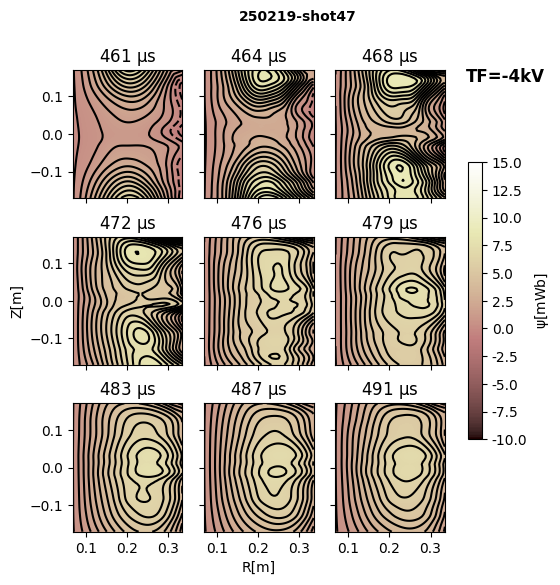

In [27]:
psi_plot(250219, 47, start=460, stop=490, lvs=200, psi_lim=[-10e-3, 15e-3], save=False)

In [30]:
np.convolve?

Signature:       np.convolve(a, v, mode='full')
Call signature:  np.convolve(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function convolve at 0x7fcdd9167100>
File:            ~/ts6/lib/python3.11/site-packages/numpy/core/numeric.py
Docstring:      
Returns the discrete, linear convolution of two one-dimensional sequences.

The convolution operator is often seen in signal processing, where it
models the effect of a linear time-invariant system on a signal [1]_.  In
probability theory, the sum of two independent random variables is
distributed according to the convolution of their individual
distributions.

If `v` is longer than `a`, the arrays are swapped before computation.

Parameters
----------
a : (N,) array_like
    First one-dimensional input array.
v : (M,) array_like
    Second one-dimensional input array.
mode : {'full', 'valid', 'same'}, optional
    'full':
      By default, mode is 'full'.  This returns the convolution
      at each point of 

In [26]:
sheet_name_cali = '250214'
sheet_id_cali = '1izM2mY1kjGAxIqMIXwhyzw1iuuMF3k5VXFJqi9Sy2U4'
url_cali = f'https://docs.google.com/spreadsheets/d/%s/gviz/tq?tqx=out:csv&sheet=%s' %(sheet_id_cali, sheet_name_cali)

cali_data = pd.read_csv(url_cali) # the calibration file.
cali_data['dtacq_num'] = cali_data['dtacq_num'].ffill() #filling the missing data

print('TS6 is now using %s calibration sheet. \nIt is recommended to specify a calibration file date before everything.\
\nRun \'set_cali_data(date)\'' %sheet_name_cali)

TS6 is now using 250214 calibration sheet. 
It is recommended to specify a calibration file date before everything.
Run 'set_cali_data(date)'


In [44]:
import matplotlib.colors as colors

In [46]:
date = 250214
shot_in_the_date = 14

start = 460
stop = 480

psi_lim = [-5e-3, 5e-3]

lvs = 50

In [47]:
# %matplotlib widget

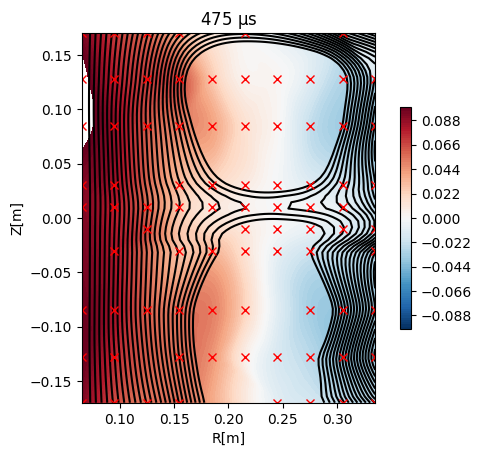

In [48]:
plt.close()
shot, tfshot, I_EF, TF_voltage = read_parameter(date, shot_in_the_date)

t = 475

R_interp, Z_interp = RZ_mesh()

times_to_plot = np.linspace(start, stop, 9, dtype=int)

fig, ax = plt.subplots()

ax.set_aspect('equal', 'box')

psi_upper, psi_lower = psi_lim
levels = np.linspace(psi_upper, psi_lower, lvs)

ax.contour(R_interp[:, 1:], Z_interp[:, 1:], psi_at_t(date, shot_in_the_date, t).T, levels=levels, colors='k')
cf = ax.contourf(R_interp, Z_interp, Bz_at_t(date, shot_in_the_date, t).T, cmap='RdBu_r', levels=np.linspace(-0.1, 0.1, 101))
# cf = ax.contourf(R_interp, Z_interp, Bz_interp_at_t(date, shot_in_the_date, t).T, cmap='RdBu_r', levels=50)
# cf = ax.pcolor(R_interp, Z_interp, Bz_interp_at_t(date, shot_in_the_date, t).T, cmap='RdBu_r')
# cf.set_clim(-0.1, 0.1)
r, z = RZ_coordinate()
ax.plot(r, z, 'rx')

ax.set_title(r'%i $\mu s$' %t)

ax.set_xlabel('R[m]')
ax.set_ylabel('Z[m]')

cbar = fig.colorbar(cf, ax=ax, shrink=0.6)

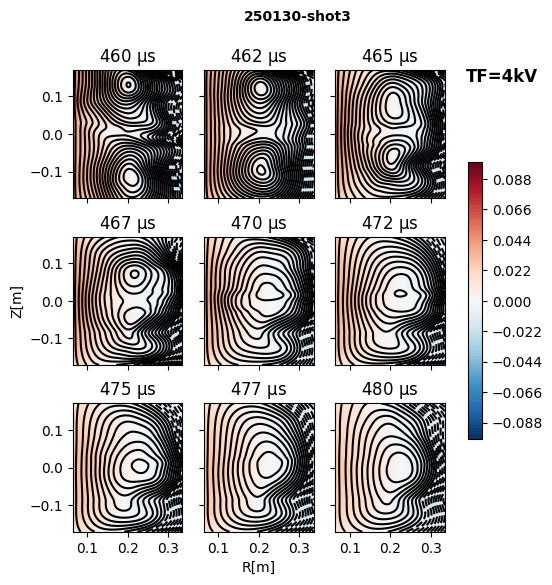

In [52]:
shot, tfshot, I_EF, TF_voltage = read_parameter(date, shot_in_the_date)

R_interp, Z_interp = RZ_mesh()

times_to_plot = np.linspace(start, stop, 9, dtype=int)


fig, ax = plt.subplots(3, 3, figsize=[6, 6])
fig.subplots_adjust(hspace=0.3)

psi_upper, psi_lower = psi_lim
levels = np.linspace(psi_upper, psi_lower, lvs)


for idx, t in enumerate(times_to_plot):
    
        i, k = [idx//3, idx%3]

        # CS = ax[i, k].contourf(R_interp[:, 1:], Z_interp[:, 1:], psi_at_t(date, shot_in_the_date, t).T, 30, cmap='pink', levels=levels)
        # ax[i, k].contour(CS, levels=CS.levels[1:-1:3], colors='k')

        ax[i, k].contour(R_interp[:, 1:], Z_interp[:, 1:], psi_at_t(date, shot_in_the_date, t).T, levels=levels, colors='k');
        cf = ax[i, k].contourf(R_interp, Z_interp, Bz_at_t(date, shot_in_the_date, t).T, cmap='RdBu_r', levels=np.linspace(-0.1, 0.1, 101));

        
        ax[i, k].set_title(r'%i $\mu s$' %t)

        # ax[i, k].plot(np.arange(0, 7) * 25e-3 + 9e-2, np.ones(7) * 2.1e-2, 'x', c='pinks', ms=4)

        if k!=0:
            ax[i, k].tick_params(labelleft=False)
        if i!=2:
            ax[i, k].tick_params(labelbottom=False)


ax[2, 1].set_xlabel('R[m]')
ax[1, 0].set_ylabel('Z[m]')

cbar = fig.colorbar(cf, ax=ax, shrink=0.6)
# cbar.set_label('$\\psi$[mWb]')

# cbar.ax.yaxis.set_major_locator(ticker.MultipleLocator(2.5e-3))
# cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '%.1f' %(x*1e3)))


fig.text(0.78, 0.86, 'TF=%ikV' %TF_voltage, fontdict={'weight':'bold', 'size':12})

fig.suptitle('%s-shot%s' %(date, shot_in_the_date), fontproperties={'weight':'bold'})


plt.show()

In [ ]:
plt.close()